<a href="https://colab.research.google.com/github/datajour-gr/ML-algorithms/blob/master/Machine_Learning_LR_updated_March26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning

## Scikit-learn

H βιβλιοθήκη sklearn αποτελείται από πολλούς και διαφορετικούς αλγορίθμους που σχετίζονται με τη μηχανική μάθηση. Είναι αρκετά απλή στη χρήση και περιέχει πολλά εργαλεία για εξόρυξη γνώσης από δεδομένα, ανάλυση και οπτικοποιήση. Έχει σχεδιαστεί ώστε να τρέχει σε περιβάλλον Python και χρειάζεται απαραιτήτως τις βιβλιοθήκες NumPy και SciPy.
![Image of operators](https://upload.wikimedia.org/wikipedia/commons/0/05/Scikit_learn_logo_small.svg)

## 1. Linear Regression

Η βιβλιοθήκη αυτή έχει ενσωματωμένες ορισμένες βάσεις δεδομένων, οπότε πριν αρχίσουμε να χρησιμοποιούμε τα δικά μας δεδομένα θα δοκιμάσουμε τη γραμμική παλινδρόμηση με τα δεδομένα από τα σπίτια της Καλιφόρνιας. Παραπάνω πληροφορίες για τα δεδομένα μπορείτε να βρείτε [εδώ](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html)


Στόχος μας είναι να προβλέψουμε την τιμή κατοικίας με τα διαθέσιμα χαρακτηριστικά στέγασης χρησιμοποιώντας την τεχνική της γραμμικής παλινδρόμησης.

Πριν ξεκινήσουμε όμως εξασκήστε τα skills σας με αυτό το τέλειο παιχνίδι ! http://guessthecorrelation.com/
    
![Image of operators](http://guessthecorrelation.com/images/guesscor_logo.svg)

#### 1. Ξεκινάμε πάντα με την εισαγωγή των απαραίτητων πακέτων και βιβλιοθηκών

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import seaborn as sns

# special matplotlib argument for improved plots
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split



#### 2. Εισάγουμε τα δεδομένα

In [4]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()


In [5]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [6]:
housing.data.shape

(20640, 8)

Ρίξτε μια ματιά στα δεδομένα σας

In [7]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

Τα δεδομένα δεν έρχονται πάντα στην μορφή που μας βολεύει γιαυτό πρέπει να μάθουμε να είμαστε ευέλικτοι και να γνωρίζουμε πως να διαχειριζόμαστε dictionaries.

> Indented block



Για την διαχείριση λεξικών με το scikit-learn πρέπει να ξέρετε τις παρακάτω εντολές:

    - .DESCR      (περιγραφή)
    - .feature_names    (ονόματα στηλών)
    - .data    (features)
    - .target    (η μεταβλητή που μας ενδιαφέρει να προβλέψουμε)
    - .filename  (θέση που αποθηκεύτηκε)

In [8]:
# Για να δούμε τα column names
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [9]:
# Για να διαβάσουμε το description του housing housing data set
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## Ας ξεκινήσουμε

In [10]:
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['PRICE'] = pd.DataFrame(housing.target)
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Τιμές που λείπουν

In [11]:
housing_df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
PRICE,0


Παρακάτω είναι μια καλή πρακτική για την εύρεση τιμών που λείπουν και έχουν εισαχθεί στα δεδομένα μας με διάφορες μορφές π.χ. "n/a", "na", "--", 999,9999. Στο συγκεκριμένο βέβαια παράδειγμα δεν φαίνεται να υπάρχουν αλλά δεν το ξέρουμε. Γιατί?

In [12]:
# ορίζουμε τις τιμές που λείπουν
missing_values = ["n/a", "na", "--", 999,9999]
# τις αλλάζουμε όνομα
housing_df.replace(to_replace = missing_values, value = np.nan, inplace = True)
# πετάμε τις γραμμές με NaNs
housing_df.dropna(inplace=True)
# Ξαναφέρνουμε το index στη σωστή σειρά, πάντα μετά από κόψιμο και πέταμα στηλών χρειάζεται reindex
housing_df.reset_index(drop=True, inplace=True)

Aν χρειάζεται να πετάξουμε χειροκίνητα κάποια συγκεκριμένη γραμμή το κάνουμε ως εξής

In [13]:
# Αν πρέπει να πετάξουμε τις γραμμές 11 και 14, τότε....
#ls_lines_to_drop = [11,14]
#housing_df.drop(ls_lines_to_drop, inplace=True)
#housing_df.head(20)

## Summary Statistics

In [14]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20618.000000,20618.000000,20618.000000,20618.000000,20618.000000,20618.000000,20618.000000,20618.000000,20618.000000
mean,3.870527,28.640363,5.428064,1.096578,1425.931807,3.070595,35.631100,-119.569013,2.068514
std,1.899795,12.585015,2.472938,0.473817,1132.980435,10.391560,2.135941,2.003510,1.153723
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563750,18.000000,4.440366,1.006090,786.250000,2.429296,33.930000,-121.800000,1.196250
50%,3.534600,29.000000,5.228400,1.048780,1167.000000,2.817937,34.260000,-118.490000,1.797000
75%,4.742600,37.000000,6.051787,1.099526,1726.000000,3.282249,37.710000,-118.010000,2.647000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Scatterplots
***
Ας δούμε μερικά γραφήματα για 3 μεταβλητές: Block group population, Average number of rooms per household και Median income in block group.  

Text(0.5, 1.0, 'Relationship between Population and Price')

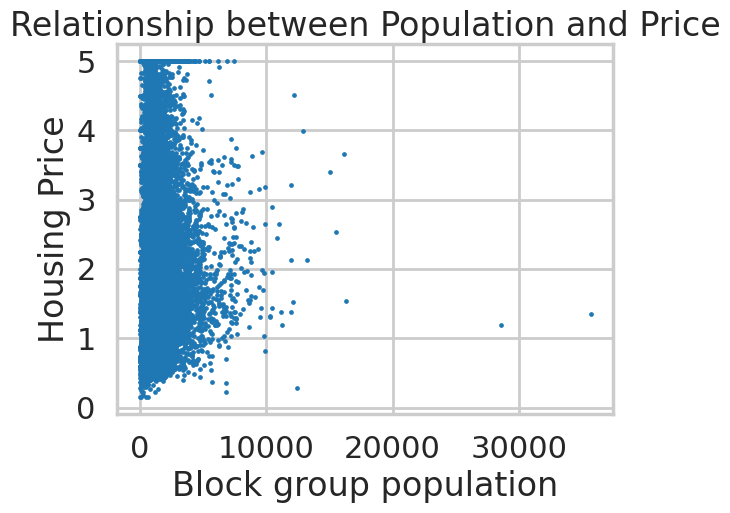

In [15]:
plt.scatter(housing_df.Population, housing_df.PRICE, s = 2)
plt.xlabel("Block group population")
plt.ylabel("Housing Price")
plt.title("Relationship between Population and Price")

## Περιγράψτε τις παρακάτω σχέσεις

Text(0.5, 1.0, 'Relationship between Rooms and Price')

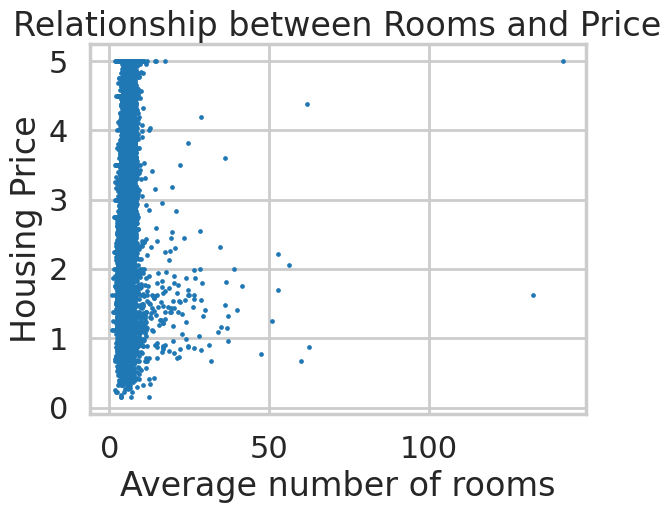

In [16]:
plt.scatter(housing_df.AveRooms, housing_df.PRICE, s = 2)
plt.xlabel("Average number of rooms")
plt.ylabel("Housing Price")
plt.title("Relationship between Rooms and Price")

Text(0.5, 1.0, 'Relationship between median income in block group and Price')

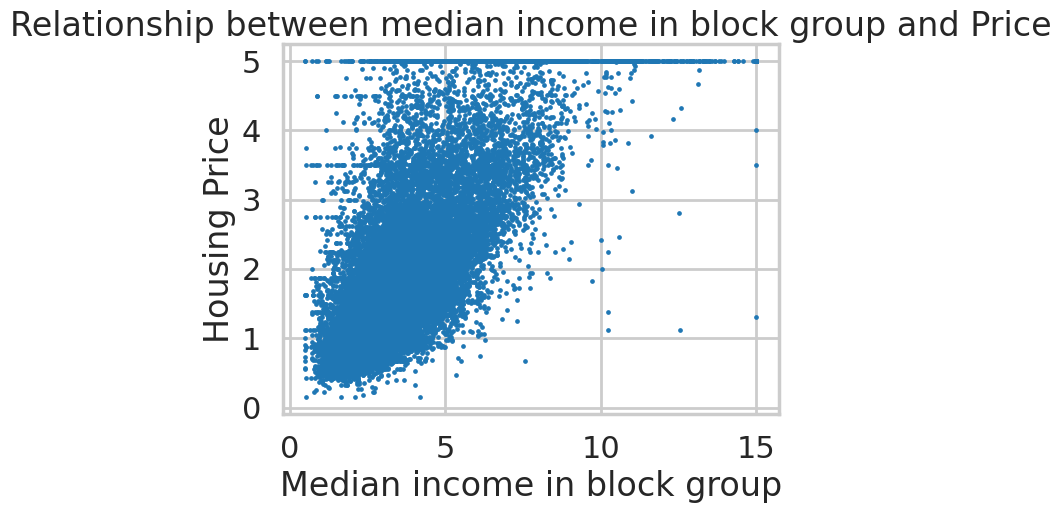

In [17]:
plt.scatter(housing_df.MedInc, housing_df.PRICE, s =2)
plt.xlabel("Median income in block group")
plt.ylabel("Housing Price")
plt.title("Relationship between median income in block group and Price")

## Φτιάξτε 2 δικά σας scatter plots και περιγράψτε τα

Διαχωρίζουμε τις ανεξάρτητες μεταβλητές Χ από την εξαρτημένη y

In [18]:
X = housing_df.drop('PRICE', axis = 1)
y = housing_df.PRICE

Φτιάχνουμε το Train και το Test set

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

## Machine Learning - regression model

Περισσότερα https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [24]:
from sklearn.linear_model import LinearRegression
# Εισαγωγή μοντέλου
lm = LinearRegression()
# Εκπαίδευση
lm.fit(X_train[['AveRooms']], y_train)
# Πρόβλεψη
y_pred = lm.predict(X_test[['AveRooms']].values)
# Υπολογισμός λάθους
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

1.1240420838395169


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Main functions | Description
--- | ---
`lm.fit()` | Fit a linear model
`lm.predit()` | Predict Y using the linear model with estimated coefficients
`lm.score()` | Returns the coefficient of determination (R^2). *A measure of how well observed outcomes are replicated by the model, as the proportion of total variation of outcomes explained by the model*

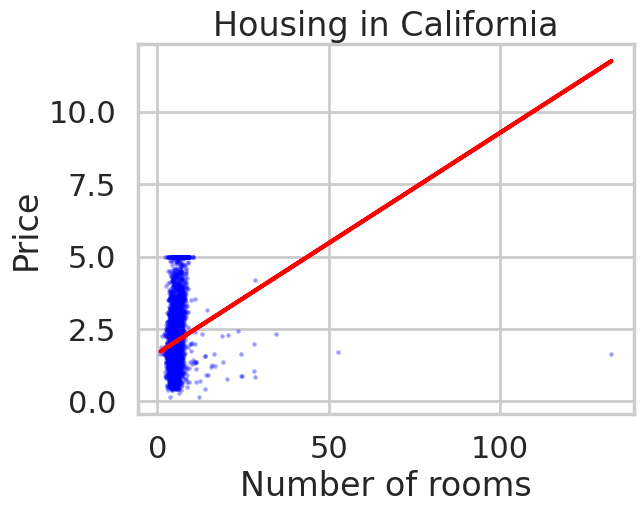

In [25]:
# Ίδιο με το επάνω
s1 = plt.scatter(X_test.AveRooms, y_test, color='b', marker='o', s = 2, alpha = 0.3) # Plot data
plt.xlabel('Number of rooms')
plt.ylabel('Price')
plt.title('Housing in California')
# Αλλά τώρα προσθέσαμε την γραμμή πρόβλεψης
plt.plot(X_test.AveRooms, y_pred, color='red') # οπτικοποιεί την πρόβλεψη
plt.savefig('lin_reg_house_rm.png', dpi=150, bbox_inches='tight') # Σώζει την εικόνα
plt.show()

Text(0.5, 1.0, 'Relationship between Rooms and Price')

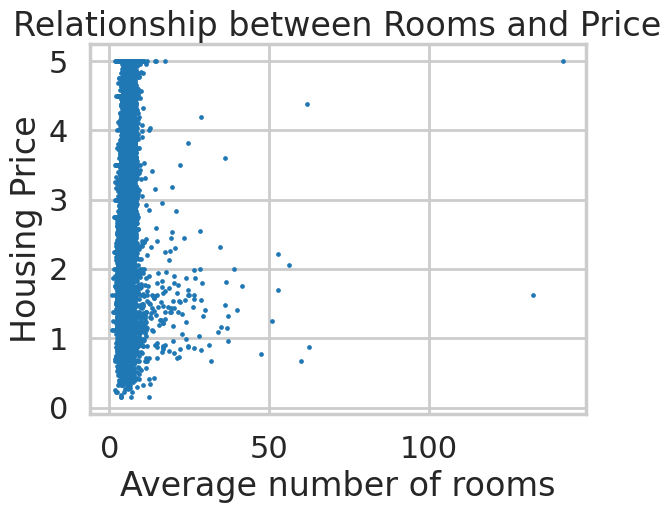

In [26]:
plt.scatter(housing_df.AveRooms, housing_df.PRICE, s = 2)
plt.xlabel("Average number of rooms")
plt.ylabel("Housing Price")
plt.title("Relationship between Rooms and Price")

### Linear regression με όλα τα χαρακτηριστικά

In [27]:

all_reg = LinearRegression()
# Εκπαίδευση
all_reg.fit(X_train, y_train)
# Υπολογισμός προβλέψεων
y_pred = all_reg.predict(X_test)
# υπολογισμός root mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# υπολογισμός r squared
r2 = round(all_reg.score(X_test, y_test), 2)
# αποτελέσματα
print('R2 score is {}'.format(r2))
print('RMSE is {}'.format(rmse))

R2 score is 0.6
RMSE is 0.7184681060457537


Επειδή δεν έχουμε μόνο μία διάσταση τώρα, αντί να τυπώσουμε 13 μικρά γραφήματα, μπορούμε να τυπώσουμε το γράφημα της πρόβλεψης σε σχέση με το πραγματικό.

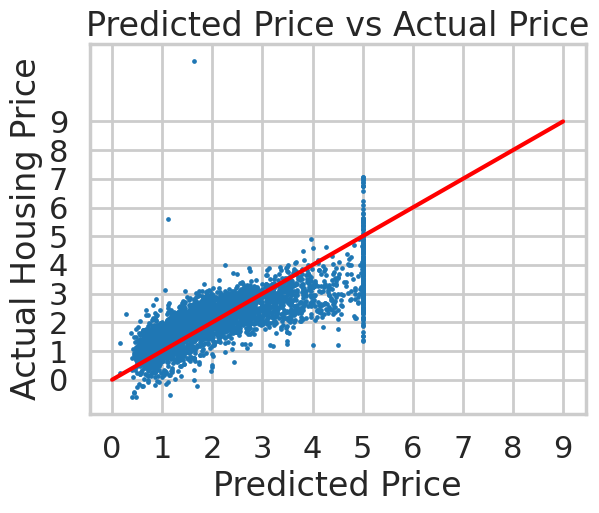

<Figure size 640x480 with 0 Axes>

In [28]:
plt.scatter(y_test, y_pred, s = 2)
plt.xlabel("Predicted Price")
plt.ylabel("Actual Housing Price")
plt.title("Predicted Price vs Actual Price")

plt.xticks(np.arange(0, 10, step=1))
plt.yticks(np.arange(0, 10, step=1))

plt.plot(np.arange(0, 10, step=1), np.arange(0, 10, step=1), color = 'red')
plt.show()
plt.clf()

## <span style="color:red">*Άσκηση*</span>

<span style="color:red">
    
Στον φάκελο week5 υπάρχει το dataset 'Bike-Sharing-Dataset' από την ιστοσελίδα του UCI https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset

, διαλέξτε ένα από τα 2 datasets, (day.csv ή hour.csv)

και επαναλάβετε τα βήματα που μάθαμε σε αυτό το notebook. Μπορείτε με γραμμική παλινδρόμηση να προβλέψετε τις ενοικιάσεις ποδηλάτων στην Washington, D.C. με βάση για παράδειγμα τον καιρό? Γράψτε μια μικρή παράγραφο με τα συμπεράσματά σας. Πριν ξεκινήσετε διαβάστε καλά την περιγραφή των δεδομένων (Attribute Information) και τι σημαίνει η κάθε στήλη!

In [29]:
# Good luck!